### Get all time related vectors from BehaviorSync and create some basic comparisons

In [43]:
from scripts.conf_file_finding import try_find_conf_file
try_find_conf_file()


Local configuration file found !!, no need to run the configuration (unless configuration has changed)


In [44]:
import u19_pipeline.ephys_pipeline as ep
import u19_pipeline.recording as recording
import matplotlib.pyplot as plt
import datajoint as dj
 


#### Select recording_id to fetch from

In [45]:
beh_key = dict()
beh_key['subject_fullname'] = 'emdia_nicky'
beh_key['session_date'] = '2026-03-23'
beh_key['session_number'] = 0
beh_key

{'subject_fullname': 'emdia_nicky',
 'session_date': '2026-03-23',
 'session_number': 0}

### Check if session exists

In [46]:
recording_beh_key = (recording.Recording.BehaviorSession & beh_key).fetch(as_dict=True)

if len(recording_beh_key) == 0:
    print('No recording data found for this session')
elif len(recording_beh_key) > 1:
    print('Multiple recordings for this behavior key, select only one')
elif len(recording_beh_key) == 1:
    recording_key = dict()
    recording_key['recording_id'] = recording_beh_key[0]['recording_id']
    print(recording_key)


{'recording_id': 625}


#### Get behaviorSync and behavior records:

In [47]:

sync_record = (ep.BehaviorSync & recording_key).fetch1('sync_data')
full_sync_record = (ep.BehaviorSync & recording_key).fetch1()

behavior = dj.create_virtual_module('behavior','u19_behavior')
behavior_session = (recording.Recording.BehaviorSession & recording_key).fetch(as_dict=True)[0]
behavior_session.pop('recording_id')
behavior_time = (behavior.SpatialTimeBlobs & behavior_session).fetch(as_dict=True)

behavior_session

{'subject_fullname': 'emdia_nicky',
 'session_date': datetime.date(2026, 3, 23),
 'session_number': 0}

"Old ephys sync variables:
**iteration_index_nidq** & **trial_index_nidq** 
are deprecated now = [nan], use sync_data column now:

In [56]:
print(full_sync_record['iteration_index_nidq'])
print(full_sync_record['iteration_index_nidq'])

[nan]
[nan]


##### Sync data description:
(using pulse aided syncing)
1. **trial_idx_vector** = nx1 numpy array. Each value of array is starting sample for each trial for each trial in the SpikeGLX full vector
2. **iteration_idx_vector** = nx1 numpy array. Each array is an array with starting sample for each iteration for each trial in the SpikeGLX full vector

(using only ViRMEn time as reference)

3. **trial_idx_vector_from_virmen** = nx1 numpy array. Each value of array is starting sample for each trial for each trial in the SpikeGLX full vector
4. **iteration_idx_vector_from_virmen** = nx1 numpy array. Each array is an array with starting sample for each iteration for each trial in the SpikeGLX full vector

In [61]:
print(sync_record['trial_idx_vector'].shape)
sync_record['trial_idx_vector'][0:100]

(311,)


array([  15679,   88423,  137615,  191793,  234401,  292120,  340828,
        407337,  453705,  514103,  565309,  624704,  675518,  734282,
        782284,  836591,  917933,  966485, 1037796, 1103762, 1158684,
       1216247, 1266647, 1316750, 1371784, 1443833, 1501338, 1555070,
       1610690, 1668537, 1726770, 1781342, 1838598, 1890732, 1957233,
       2028585, 2084947, 2175840, 2229835, 2299039, 2359040, 2415628,
       2472803, 2531417, 2587689, 2662404, 2742205, 2800742, 2862290,
       2921679, 2978891, 3039436, 3097504, 3159807, 3215045, 3274957,
       3327095, 3387013, 3448942, 3548462, 3602619, 3683597, 3739502,
       3798351, 3867689, 3925606, 4003038, 4073647, 4147062, 4207807,
       4301836, 4358259, 4420951, 4488051, 4562475, 4642750, 4704722,
       4781318, 4837479, 4909732, 4969717, 5040393, 5108712, 5166776,
       5223000, 5293807, 5358403, 5432765, 5562999, 5616580, 5673342,
       5736017, 5810221, 5866920, 5926454, 5983133, 6053636, 6129068,
       6204703, 6265

#### To get "full" vectors (Same size as SpikeGLX recordings) use:
**ephys_pipeline.get_full_vectors_from_key** function

In [62]:
all_vectors = ep.get_full_vectors_from_key(recording_key)
all_vectors.keys()

ephys dir: /mnt/cup/braininit/Data/Raw/electrophysiology/emdia/emdia_nicky/20260323_g0/20260323_g0


dict_keys(['trial_index_nidq_virmen', 'iteration_index_nidq_virmen', 'trial_index_nidq', 'iteration_index_nidq', 'time_vector', 'time_as_behavior_trial_ind', 'time_as_behavior_fullsession', 'time_as_behavior_trial_ind_virmen', 'time_as_behavior_fullsession_virmen'])

#### Concatenate arrays of arrays vectors to get single vector time variables

In [52]:
import numpy as np
time_as_behavior_fullsession = np.concatenate(([x for x in all_vectors['time_as_behavior_fullsession']]), axis=0) 
time_as_behavior_trial_ind = np.concatenate(([x for x in all_vectors['time_as_behavior_trial_ind']]), axis=0) 



#### Compare behvaior file time variables vs BehaviorSync ones 

In [53]:
diff_time_trial_ind = behavior_time[0]['trial_time'].squeeze() - time_as_behavior_trial_ind
diff_time_trial_full_session = (behavior_time[0]['cumulative_session_time'].squeeze() - behavior_time[0]['cumulative_session_time'][0]) - time_as_behavior_fullsession


#### "pulse only sync" single vector time for all session [0, ...] x 1
#### Compare nidaq signal for behavior iteration "start time".

Text(0.5, 1.0, 'iteration "start time" comparison -- behavior file - nidaq pulse signal. Single vector time all session')

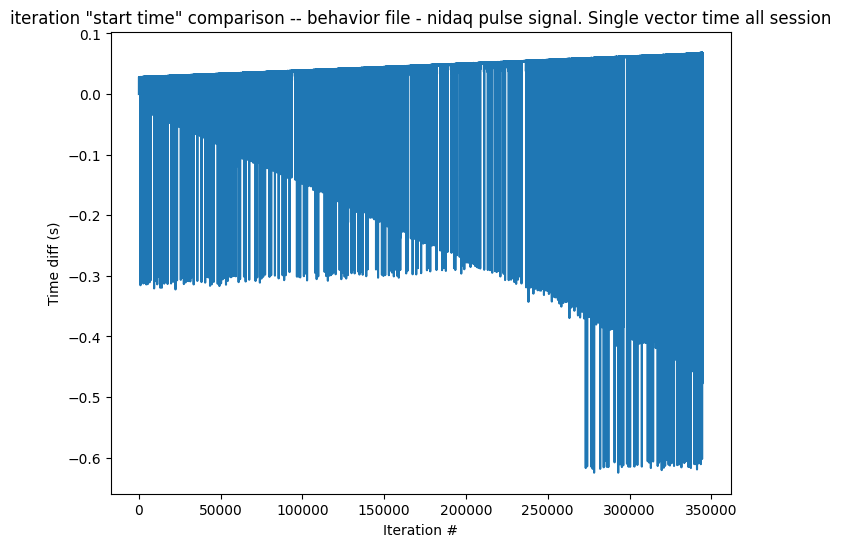

In [54]:
plt.figure(figsize=(8, 6))
plt.plot(diff_time_trial_full_session)

plt.xlabel('Iteration #')
plt.ylabel('Time diff (s)')
plt.title('iteration "start time" comparison -- behavior file - nidaq pulse signal. Single vector time all session')

Text(0.5, 1.0, 'iteration "start time" Histogram -- behavior file - nidaq pulse signal. Single vector time all session')

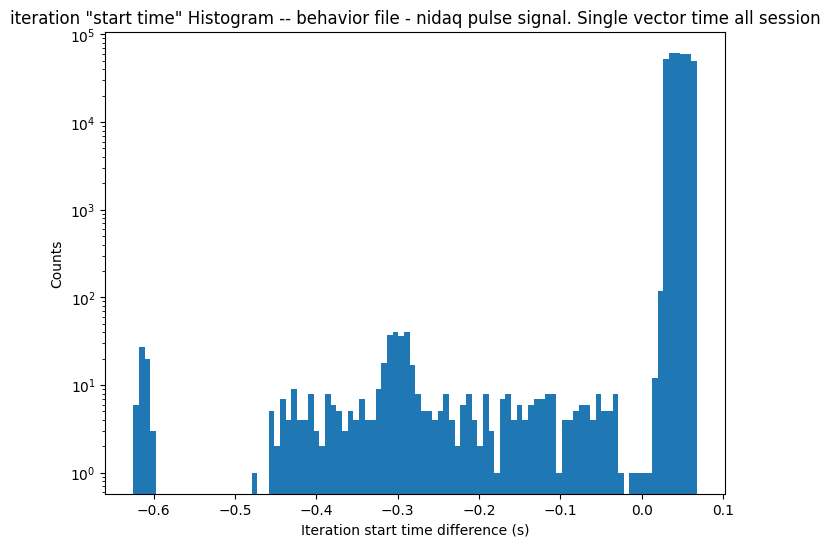

In [55]:
plt.figure(figsize=(8, 6))

plt.hist(diff_time_trial_full_session,bins=100)

plt.yscale('log')
plt.xlabel('Iteration start time difference (s)')
plt.ylabel('Counts')
plt.title('iteration "start time" Histogram -- behavior file - nidaq pulse signal. Single vector time all session')

